# 🕵️ Detector de Fake News — Terceira Etapa
## Processamento de Linguagem Natural Avançado com spaCy + Transformers

Esta etapa aprofunda a análise linguística do corpus WELFake, cobrindo:
- **Tokenização, Normalização e Lematização**
- **POS Tagging** (Part-of-Speech)
- **Noun Chunks** (Sintagmas nominais)
- **NER** (Named Entity Recognition)
- **Segmentação de Sentenças**
- **Classificação de Textos** com múltiplos modelos
- **Análise de Sentimentos** com Embeddings e Transformers
- **Visualizações** em cada etapa

---
## 0. Setup e Carregamento dos Dados

In [1]:
# Instalações necessárias (execute uma vez)
!pip install transformers torch spacy matplotlib seaborn wordcloud sentence-transformers
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 4.4 MB/s eta 0:00:03
     ---- ----------------------------------- 1.6/12.8 MB 4.1 MB/s eta 0:00:03
     -------- ------------------------------- 2.6/12.8 MB 4.4 MB/s eta 0:00:03
     ------------- -------------------------- 4.2/12.8 MB 5.3 MB/s eta 0:00:02
     ------------------ --------------------- 5.8/12.8 MB 5.8 MB/s eta 0:00:02
     ------------------------ --------------- 7.9/12.8 MB 6.5 MB/s eta 0:00:01
     ----------------------------- ---------- 9.4/12.8 MB 7.0 MB/s eta 0:00:01
     ----------------------------------- ---- 11.3/12.8 MB 7.0 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 7.0 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 6.6 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
import pandas as pd
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Download do dataset WELFake
path = kagglehub.dataset_download("saurabhshahane/fake-news-classification")
df_full = pd.read_csv(os.path.join(path, "WELFake_Dataset.csv"))
df_full = df_full.dropna(subset=['title', 'text'])
df_full['label_str'] = df_full['label'].map({1: 'FAKE', 0: 'REAL'})

# Amostra balanceada de 200 notícias (100 Fake + 100 Real) para análises NLP
df = pd.concat([
    df_full[df_full['label'] == 0].sample(100, random_state=42),
    df_full[df_full['label'] == 1].sample(100, random_state=42)
]).reset_index(drop=True)

print(f"Dataset completo: {len(df_full):,} notícias")
print(f"Amostra para análise NLP: {len(df)} notícias (100 REAL + 100 FAKE)")
df[['title', 'text', 'label_str']].head(5)

c:\Users\pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset completo: 71,537 notícias
Amostra para análise NLP: 200 notícias (100 REAL + 100 FAKE)


,title,text,label_str
0,Two People Die after Eating Raw-Milk Cheese Ma...,Two people have died following an outbreak of ...,REAL
1,DUP blames Sinn Fein for Northern Ireland talk...,BELFAST (Reuters) - A senior member of Norther...,REAL
2,Exclusive: Former top Brazil prosecutor says s...,BRASILIA (Reuters) - Three senior Brazilian la...,REAL
3,U.S. intelligence chief says Russia involvemen...,WASHINGTON (Reuters) - U.S. Director of Nation...,REAL
4,Macri's coalition poised to win key Argentina ...,BUENOS AIRES (Reuters) - Argentine President M...,REAL


---
## 1. Tokenização, Normalização e Lematização
Aplicamos o pipeline do spaCy com **parser** e **NER habilitados** para extrair todas as informações linguísticas.

In [3]:
import spacy
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Pipeline COMPLETO (parser + ner habilitados para esta etapa)
nlp = spacy.load("en_core_web_sm")

# Processamos o título de cada notícia (mais rápido e representativo)
df['content'] = df['title'] + ". " + df['text'].str[:300]

print("Processando pipeline spaCy...")
docs = list(tqdm(nlp.pipe(df['content'], batch_size=50), total=len(df)))
df['doc'] = docs
print("Concluído!")

Processando pipeline spaCy...


100%|██████████| 200/200 [00:05<00:00, 37.67it/s]

Concluído!


In [4]:
# Exemplo detalhado: Tokenização, Normalização e Lematização
exemplo = df['doc'].iloc[0]
print(f"Texto original (primeiros 120 chars): {df['content'].iloc[0][:120]}\n")
print(f"{'TOKEN':<20} {'NORMALIZADO':<20} {'LEMA':<20} {'STOP?':<8} {'PUNCT?'}")
print("-" * 75)
for token in list(exemplo)[:15]:
    print(f"{token.text:<20} {token.norm_:<20} {token.lemma_:<20} {str(token.is_stop):<8} {token.is_punct}")

Texto original (primeiros 120 chars): Two People Die after Eating Raw-Milk Cheese Made in New York State - The New York Times. Two people have died following 

TOKEN                NORMALIZADO          LEMA                 STOP?    PUNCT?
---------------------------------------------------------------------------
Two                  two                  two                  True     False
People               people               People               False    False
Die                  die                  die                  False    False
after                after                after                True     False
Eating               eating               eat                  False    False
Raw                  raw                  Raw                  False    False
-                    -                    -                    False    True
Milk                 milk                 Milk                 False    False
Cheese               cheese               Cheese              

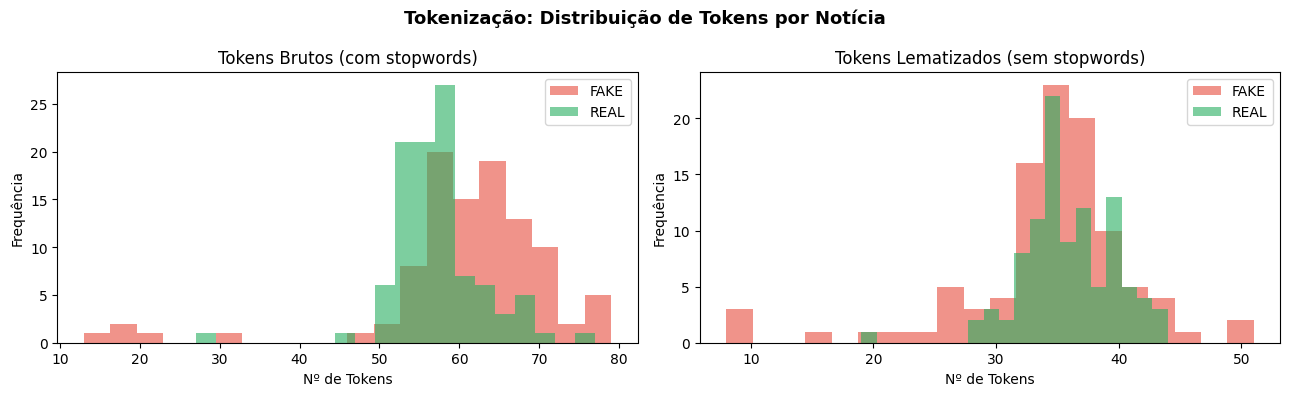

Redução média de tokens após lematização: 59 → 35


In [5]:
# Comparação: texto bruto vs lematizado
def lematizar(doc):
    return " ".join([t.lemma_ for t in doc if not t.is_stop and not t.is_punct and t.is_alpha])

df['lemmatized'] = df['doc'].apply(lematizar)

# Contagem de tokens antes e depois da lematização
df['n_tokens_raw'] = df['doc'].apply(lambda d: len([t for t in d if t.is_alpha]))
df['n_tokens_lem'] = df['lemmatized'].apply(lambda t: len(t.split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Tokenização: Distribuição de Tokens por Notícia', fontsize=13, fontweight='bold')

for ax, col, title, color in zip(
    axes,
    ['n_tokens_raw', 'n_tokens_lem'],
    ['Tokens Brutos (com stopwords)', 'Tokens Lematizados (sem stopwords)'],
    ['#4A90D9', '#E8734A']
):
    for label, group in df.groupby('label_str'):
        ax.hist(group[col], bins=20, alpha=0.6, label=label,
                color='#e74c3c' if label=='FAKE' else '#27ae60')
    ax.set_title(title)
    ax.set_xlabel('Nº de Tokens')
    ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.savefig('grafico_tokenizacao.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Redução média de tokens após lematização: {df['n_tokens_raw'].mean():.0f} → {df['n_tokens_lem'].mean():.0f}")

---
## 2. POS Tagging (Part-of-Speech)
Identificamos as categorias gramaticais dos tokens: substantivos, verbos, adjetivos, etc.

In [6]:
from collections import Counter

# Exemplo de POS Tagging
print("Exemplo de POS Tagging:\n")
print(f"{'TOKEN':<20} {'POS':<12} {'TAG':<10} {'DESCRIÇÃO'}")
print("-" * 65)
for token in list(df['doc'].iloc[3])[:12]:
    if not token.is_space:
        print(f"{token.text:<20} {token.pos_:<12} {token.tag_:<10} {spacy.explain(token.tag_) or ''}")

Exemplo de POS Tagging:

TOKEN                POS          TAG        DESCRIÇÃO
-----------------------------------------------------------------
U.S.                 PROPN        NNP        noun, proper singular
intelligence         NOUN         NN         noun, singular or mass
chief                NOUN         NN         noun, singular or mass
says                 VERB         VBZ        verb, 3rd person singular present
Russia               PROPN        NNP        noun, proper singular
involvement          NOUN         NN         noun, singular or mass
in                   ADP          IN         conjunction, subordinating or preposition
2016                 NUM          CD         cardinal number
election             NOUN         NN         noun, singular or mass
unprecedented        ADJ          JJ         adjective (English), other noun-modifier (Chinese)
.                    PUNCT        .          punctuation mark, sentence closer
WASHINGTON           PROPN        NNP        n

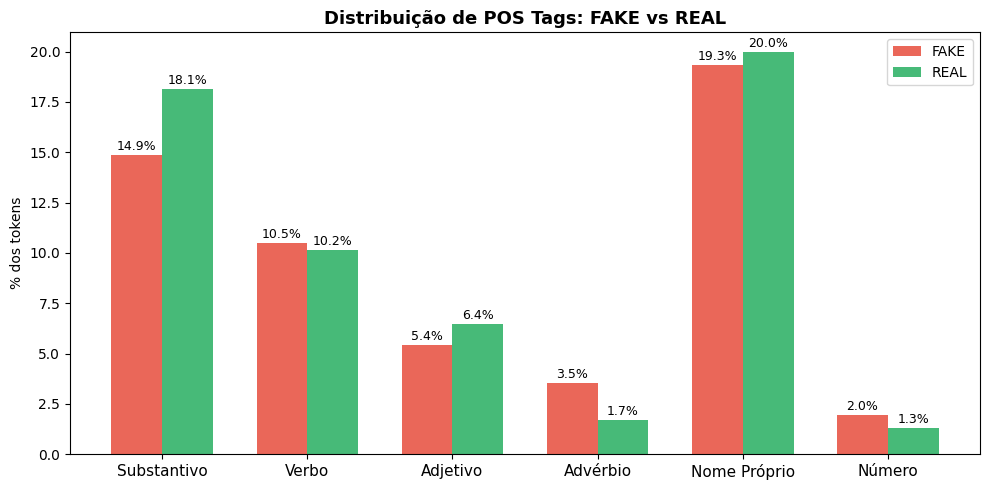

In [7]:
# Distribuição de POS por classe (FAKE vs REAL)
pos_interest = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN', 'NUM']
pos_labels = {'NOUN': 'Substantivo', 'VERB': 'Verbo', 'ADJ': 'Adjetivo',
              'ADV': 'Advérbio', 'PROPN': 'Nome Próprio', 'NUM': 'Número'}

pos_data = {}
for label in ['FAKE', 'REAL']:
    docs_label = df[df['label_str'] == label]['doc']
    all_pos = [t.pos_ for doc in docs_label for t in doc if not t.is_space]
    total = len(all_pos)
    pos_data[label] = {p: all_pos.count(p)/total*100 for p in pos_interest}

pos_df = pd.DataFrame(pos_data).rename(index=pos_labels)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(pos_df))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], pos_df['FAKE'], width, label='FAKE', color='#e74c3c', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], pos_df['REAL'], width, label='REAL', color='#27ae60', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(pos_df.index, fontsize=11)
ax.set_ylabel('% dos tokens')
ax.set_title('Distribuição de POS Tags: FAKE vs REAL', fontsize=13, fontweight='bold')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('grafico_pos_tagging.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Noun Chunks (Sintagmas Nominais)
Extraímos os grupos nominais — expressões compostas que formam uma unidade de significado.

In [8]:
# Exemplo de Noun Chunks
doc_exemplo = df['doc'].iloc[5]
print(f"Texto: {df['content'].iloc[5][:200]}\n")
print("Noun Chunks encontrados:")
for chunk in doc_exemplo.noun_chunks:
    print(f"  → '{chunk.text}'  |  raiz: '{chunk.root.text}' ({chunk.root.dep_})")

Texto: ¿Qué bolá? Obama jokes with Cuban humorist in video. HAVANA (Reuters) - U.S. President Barack Obama tried out his comedic chops with some Spanish in a video he made with Cuban humorist Pánfilo ahead o

Noun Chunks encontrados:
  → '¿Qué bolá'  |  raiz: 'bolá' (ROOT)
  → 'Obama'  |  raiz: 'Obama' (nsubj)
  → 'Cuban humorist'  |  raiz: 'humorist' (pobj)
  → 'video'  |  raiz: 'video' (pobj)
  → '(Reuters'  |  raiz: 'Reuters' (appos)
  → 'his comedic chops'  |  raiz: 'chops' (dobj)
  → 'some Spanish'  |  raiz: 'Spanish' (pobj)
  → 'a video'  |  raiz: 'video' (pobj)
  → 'he'  |  raiz: 'he' (nsubj)
  → 'Cuban humorist'  |  raiz: 'humorist' (pobj)
  → 'Pánfilo'  |  raiz: 'Pánfilo' (appos)
  → 'a historic visit'  |  raiz: 'visit' (pobj)
  → 'Havana'  |  raiz: 'Havana' (pobj)
  → 'Obama'  |  raiz: 'Obama' (nsubj)
  → 'who'  |  raiz: 'who' (nsubj)
  → 'praise'  |  raiz: 'praise' (dobj)
  → 'professional comedians'  |  raiz: 'comedians' (pobj)
  → 'his comic timing'  |  raiz: 'timing' (pob

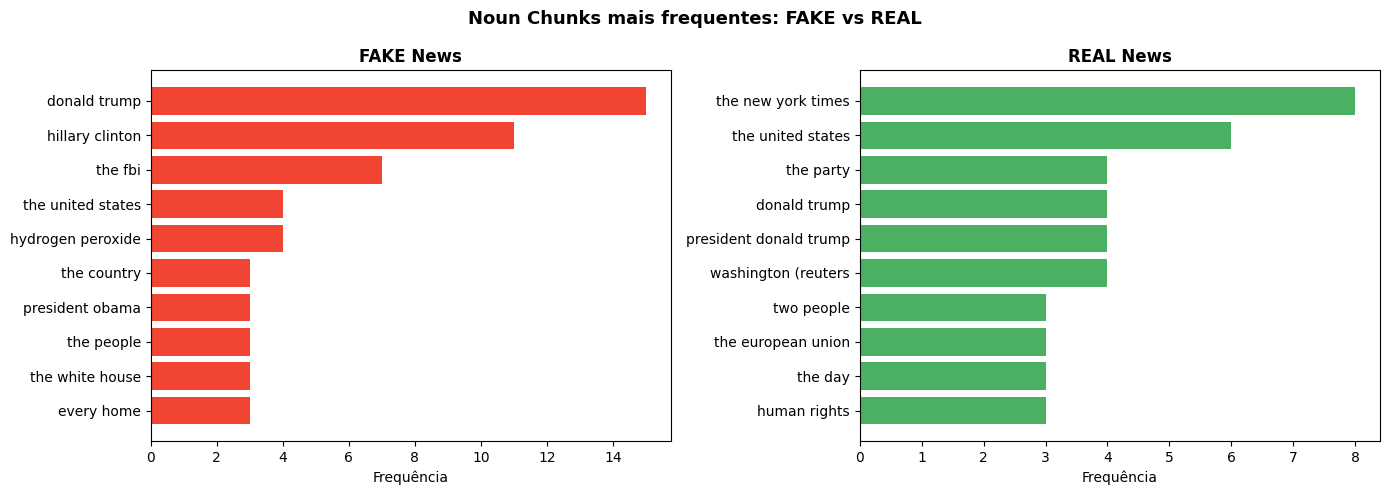

In [9]:
from wordcloud import WordCloud

# Noun Chunks mais frequentes por classe
def get_chunks(docs_series):
    chunks = []
    for doc in docs_series:
        chunks.extend([chunk.text.lower().strip() for chunk in doc.noun_chunks
                       if len(chunk.text.split()) > 1])
    return Counter(chunks)

chunks_fake = get_chunks(df[df['label_str']=='FAKE']['doc'])
chunks_real = get_chunks(df[df['label_str']=='REAL']['doc'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Noun Chunks mais frequentes: FAKE vs REAL', fontsize=13, fontweight='bold')

for ax, chunks, title, cmap in zip(
    axes,
    [chunks_fake, chunks_real],
    ['FAKE News', 'REAL News'],
    ['Reds', 'Greens']
):
    top10 = dict(chunks.most_common(10))
    ax.barh(list(top10.keys())[::-1], list(top10.values())[::-1],
            color=plt.cm.get_cmap(cmap)(0.6))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequência')

plt.tight_layout()
plt.savefig('grafico_noun_chunks.png', dpi=120, bbox_inches='tight')
plt.show()

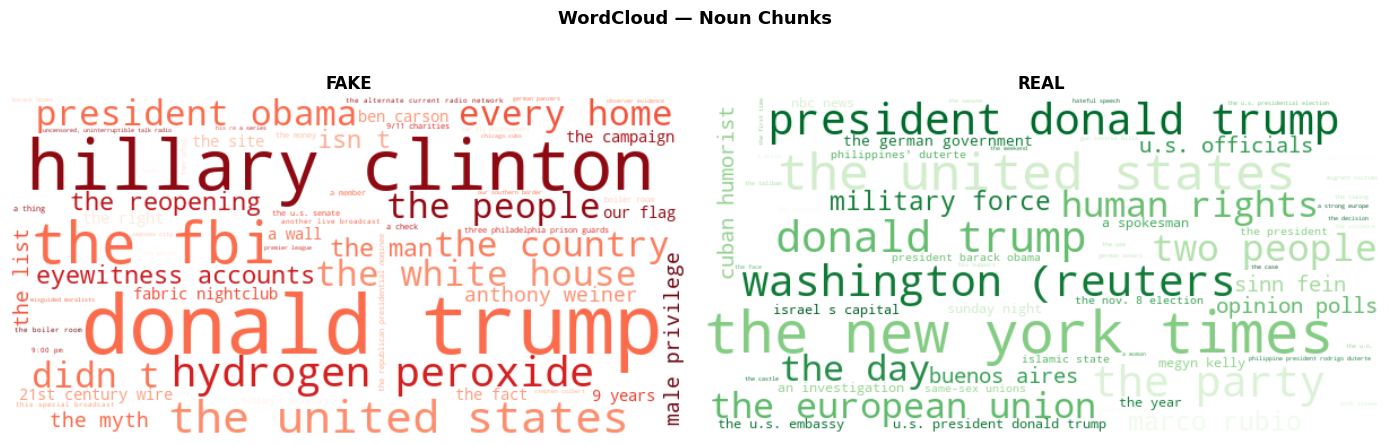

In [10]:
# WordCloud dos Noun Chunks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('WordCloud — Noun Chunks', fontsize=13, fontweight='bold')

for ax, chunks, title, color in zip(
    axes, [chunks_fake, chunks_real], ['FAKE', 'REAL'], ['Reds', 'Greens']
):
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap=color, max_words=60).generate_from_frequencies(chunks)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('grafico_wordcloud_chunks.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. NER — Reconhecimento de Entidades Nomeadas
Identificamos pessoas, organizações, locais, datas e outros tipos de entidades no corpus.

In [11]:
# Exemplo visual de NER
from spacy import displacy

# Encontra uma notícia com bastante entidades
doc_ner = sorted(df['doc'], key=lambda d: len(d.ents), reverse=True)[0]
print(f"Texto analisado: {doc_ner.text[:300]}\n")
print(f"{'ENTIDADE':<30} {'TIPO':<12} {'DESCRIÇÃO'}")
print("-" * 65)
for ent in doc_ner.ents[:15]:
    print(f"{ent.text:<30} {ent.label_:<12} {spacy.explain(ent.label_) or ''}")

Texto analisado: U.S. reaffirms 'One China' policy to Beijing after Trump: White House. WASHINGTON (Reuters) - The United States has been in touch with Chinese officials to reassure them that it is adhering to the “One China” policy after President-elect Donald Trump’s telephone call with the Taiwan’s leader last we

ENTIDADE                       TIPO         DESCRIÇÃO
-----------------------------------------------------------------
U.S.                           GPE          Countries, cities, states
One                            CARDINAL     Numerals that do not fall under another type
China                          GPE          Countries, cities, states
Beijing                        GPE          Countries, cities, states
Trump                          PERSON       People, including fictional
White House                    ORG          Companies, agencies, institutions, etc.
WASHINGTON                     ORG          Companies, agencies, institutions, etc.
Reuters               

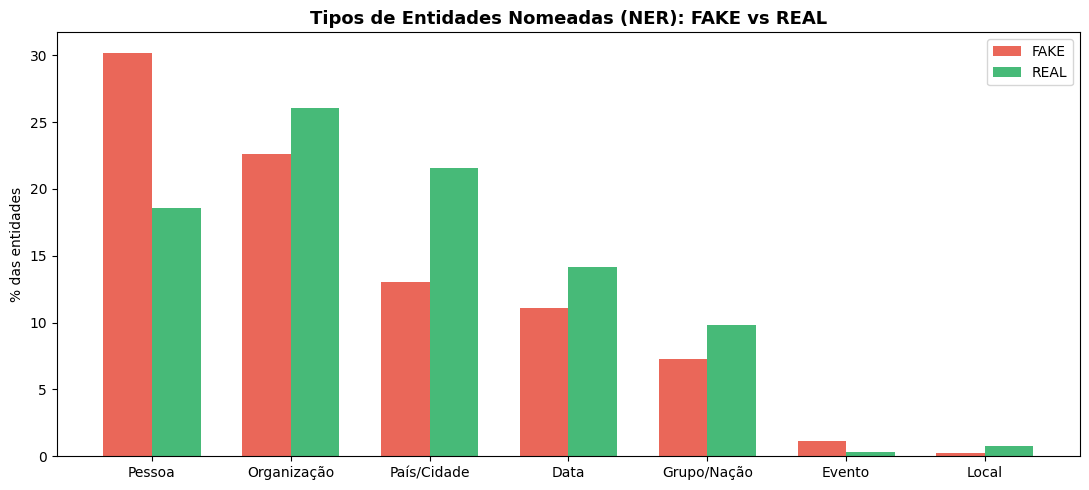

In [12]:
# Distribuição dos tipos de entidade: FAKE vs REAL
ent_types_interest = ['PERSON', 'ORG', 'GPE', 'DATE', 'NORP', 'EVENT', 'LOC']
ent_labels_pt = {'PERSON': 'Pessoa', 'ORG': 'Organização', 'GPE': 'País/Cidade',
                 'DATE': 'Data', 'NORP': 'Grupo/Nação', 'EVENT': 'Evento', 'LOC': 'Local'}

ent_data = {}
for label in ['FAKE', 'REAL']:
    docs_label = df[df['label_str'] == label]['doc']
    all_ents = [ent.label_ for doc in docs_label for ent in doc.ents]
    total = max(len(all_ents), 1)
    ent_data[label] = {e: all_ents.count(e)/total*100 for e in ent_types_interest}

ent_df = pd.DataFrame(ent_data).rename(index=ent_labels_pt)

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(ent_df))
width = 0.35
b1 = ax.bar([i - width/2 for i in x], ent_df['FAKE'], width, label='FAKE', color='#e74c3c', alpha=0.85)
b2 = ax.bar([i + width/2 for i in x], ent_df['REAL'], width, label='REAL', color='#27ae60', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(ent_df.index, fontsize=10)
ax.set_ylabel('% das entidades')
ax.set_title('Tipos de Entidades Nomeadas (NER): FAKE vs REAL', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('grafico_ner.png', dpi=120, bbox_inches='tight')
plt.show()

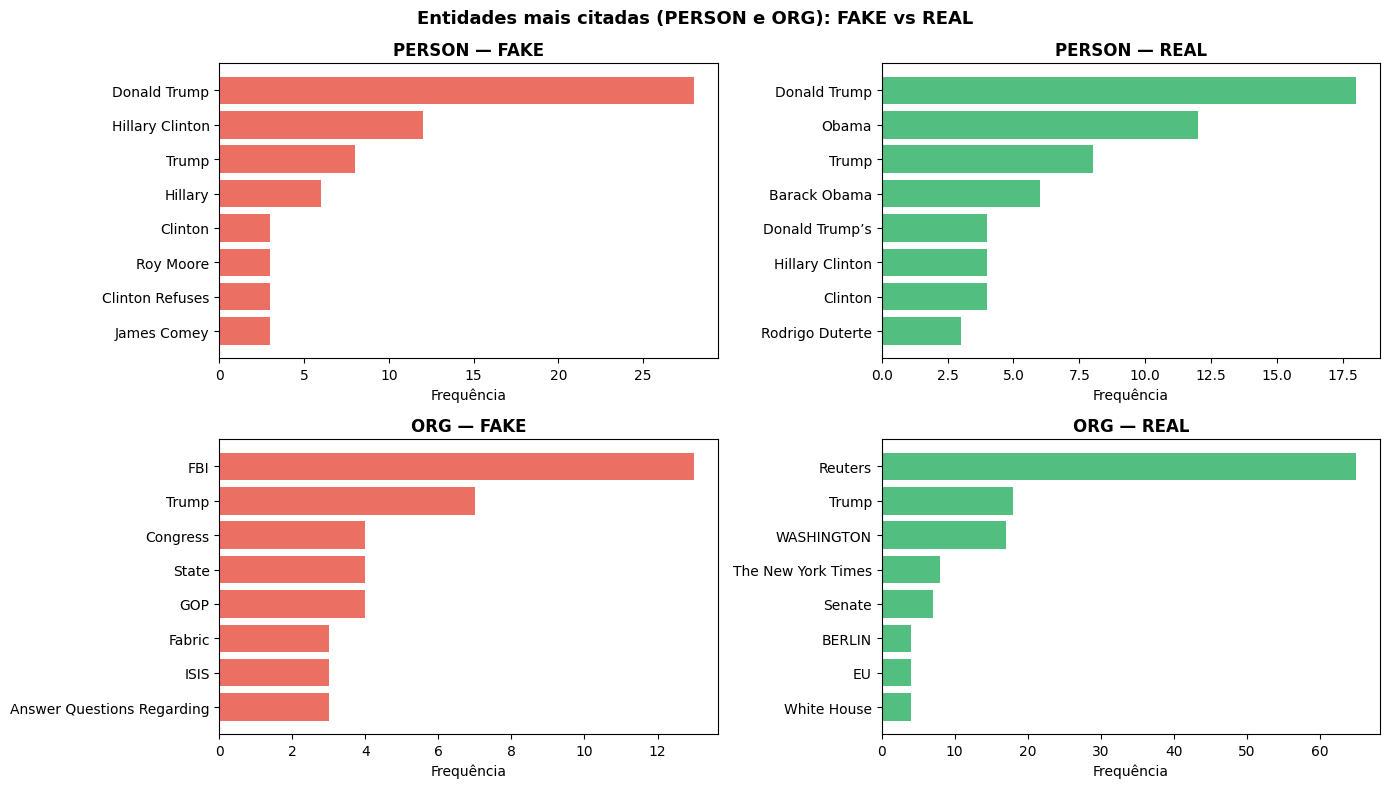

In [13]:
# Top entidades do tipo PERSON e ORG em cada classe
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Entidades mais citadas (PERSON e ORG): FAKE vs REAL', fontsize=13, fontweight='bold')

for row, ent_type in enumerate(['PERSON', 'ORG']):
    for col, label in enumerate(['FAKE', 'REAL']):
        docs_label = df[df['label_str'] == label]['doc']
        ents = [ent.text for doc in docs_label for ent in doc.ents if ent.label_ == ent_type]
        top = Counter(ents).most_common(8)
        if top:
            names, counts = zip(*top)
            color = '#e74c3c' if label == 'FAKE' else '#27ae60'
            axes[row][col].barh(list(names)[::-1], list(counts)[::-1], color=color, alpha=0.8)
            axes[row][col].set_title(f'{ent_type} — {label}', fontweight='bold')
            axes[row][col].set_xlabel('Frequência')

plt.tight_layout()
plt.savefig('grafico_ner_top_entidades.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Segmentação de Sentenças
Analisamos quantas sentenças e qual o comprimento médio em notícias FAKE vs REAL.

In [14]:
# Exemplo de segmentação
doc_seg = df['doc'].iloc[10]
print(f"Texto: {df['content'].iloc[10][:250]}\n")
print("Sentenças detectadas:")
for i, sent in enumerate(doc_seg.sents, 1):
    print(f"  [{i}] {sent.text.strip()}")

Texto: Applications Open For the Yiannopoulos Privilege Grant - Breitbart. Applications for the Yiannopoulos Privilege Grant, a college tuition grant created by Breitbart News Senior Editor MILO exclusively for white men, are now being accepted.[  “The Yian

Sentenças detectadas:
  [1] Applications Open For the Yiannopoulos Privilege Grant - Breitbart.
  [2] Applications for the Yiannopoulos Privilege Grant, a college tuition grant created by Breitbart News Senior Editor MILO exclusively for white men, are now being accepted.[  “The Yiannopoulos Privilege Grant, launched by Milo Yiannopoulos and funded by Milo and private donors to provide college fundi


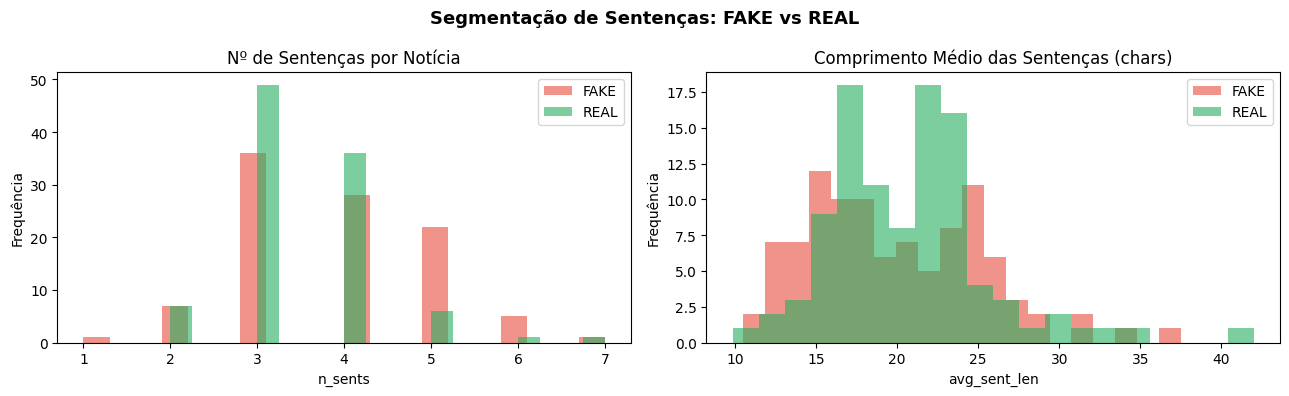


Média por classe:
           n_sents  avg_sent_len
label_str                       
FAKE          3.82         19.91
REAL          3.48         20.72


In [15]:
# Métricas de segmentação por classe
df['n_sents'] = df['doc'].apply(lambda d: len(list(d.sents)))
df['avg_sent_len'] = df['doc'].apply(
    lambda d: sum(len(s) for s in d.sents) / max(len(list(d.sents)), 1)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Segmentação de Sentenças: FAKE vs REAL', fontsize=13, fontweight='bold')

for ax, col, title in zip(
    axes,
    ['n_sents', 'avg_sent_len'],
    ['Nº de Sentenças por Notícia', 'Comprimento Médio das Sentenças (chars)']
):
    for label, color in [('FAKE', '#e74c3c'), ('REAL', '#27ae60')]:
        ax.hist(df[df['label_str']==label][col], bins=20, alpha=0.6, label=label, color=color)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.savefig('grafico_segmentacao.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nMédia por classe:")
print(df.groupby('label_str')[['n_sents', 'avg_sent_len']].mean().round(2))

---
## 6. Classificação de Textos
Comparamos múltiplos classificadores usando TF-IDF como representação vetorial.

In [16]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier, LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Usamos o dataset COMPLETO para classificação
df_full['content'] = df_full['title'] + " " + df_full['text']

# Limpeza básica (sem spaCy para escalar)
def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', str(text))
    return re.sub(r'[^a-zA-Z\s]', '', text).lower().strip()

df_full['clean'] = df_full['content'].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df_full['clean'], df_full['label'], test_size=0.2, random_state=42
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print(f"Treino: {X_train_vec.shape[0]:,} | Teste: {X_test_vec.shape[0]:,} amostras")
print(f"Vocabulário TF-IDF: {X_train_vec.shape[1]:,} features")

Treino: 57,229 | Teste: 14,308 amostras
Vocabulário TF-IDF: 5,000 features


In [17]:
# Treinamento e avaliação de 4 classificadores
classifiers = {
    'Passive Aggressive': PassiveAggressiveClassifier(max_iter=50, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Linear SVC': LinearSVC(max_iter=1000, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': clf, 'accuracy': acc, 'y_pred': y_pred}
    print(f"{name:<25} Acurácia: {acc*100:.2f}%")

best_name = max(results, key=lambda k: results[k]['accuracy'])
print(f"\n🏆 Melhor modelo: {best_name} ({results[best_name]['accuracy']*100:.2f}%)")

Passive Aggressive        Acurácia: 96.23%
Logistic Regression       Acurácia: 96.27%
Naive Bayes               Acurácia: 86.57%
Linear SVC                Acurácia: 96.73%

🏆 Melhor modelo: Linear SVC (96.73%)


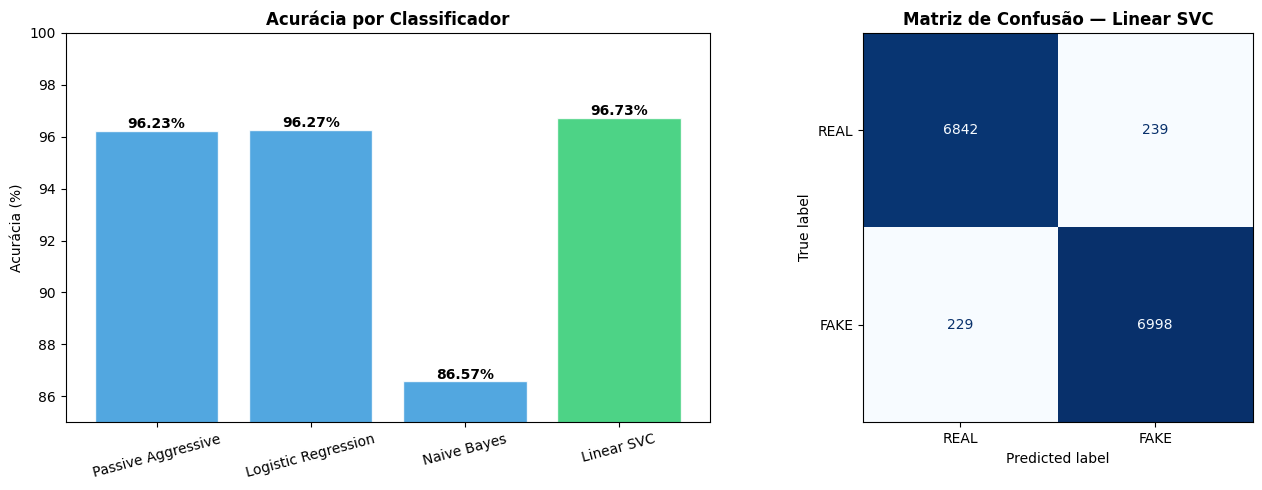


Relatório completo — Linear SVC:
              precision    recall  f1-score   support

        REAL       0.97      0.97      0.97      7081
        FAKE       0.97      0.97      0.97      7227

    accuracy                           0.97     14308
   macro avg       0.97      0.97      0.97     14308
weighted avg       0.97      0.97      0.97     14308



In [18]:
# Gráfico de comparação de acurácias
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de acurácia
names = list(results.keys())
accs = [results[n]['accuracy']*100 for n in names]
colors = ['#2ecc71' if n == best_name else '#3498db' for n in names]

bars = axes[0].bar(names, accs, color=colors, alpha=0.85, edgecolor='white')
axes[0].set_ylim([85, 100])
axes[0].set_title('Acurácia por Classificador', fontweight='bold')
axes[0].set_ylabel('Acurácia (%)')
axes[0].tick_params(axis='x', rotation=15)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                 f'{acc:.2f}%', ha='center', fontsize=10, fontweight='bold')

# Confusion Matrix do melhor modelo
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['REAL', 'FAKE'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Matriz de Confusão — {best_name}', fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_classificadores.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nRelatório completo — {best_name}:")
print(classification_report(y_test, results[best_name]['y_pred'], target_names=['REAL', 'FAKE']))

---
## 7. Análise de Sentimentos com Embeddings e Transformers
Utilizamos o modelo `cardiffnlp/twitter-roberta-base-sentiment-latest` (HuggingFace) — treinado em ~58M tweets — para classificar o sentimento de cada notícia.

In [19]:
from transformers import pipeline

print("Carregando modelo de sentimentos (HuggingFace)...")
# Modelo leve, mas robusto para textos jornalísticos/notícias
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512
)
print("Modelo carregado!")

Carregando modelo de sentimentos (HuggingFace)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8556.68it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo carregado!


In [20]:
# Rodamos o sentiment analysis na amostra de 200 notícias
# Usamos só o título (mais rápido e dentro do limite de tokens)
print("Analisando sentimentos (200 notícias)...")
titles = df['title'].tolist()

# Batch processing para eficiência
sentiment_results = []
batch_size = 16
for i in tqdm(range(0, len(titles), batch_size)):
    batch = titles[i:i+batch_size]
    results_batch = sentiment_pipeline(batch)
    sentiment_results.extend(results_batch)

df['sentiment'] = [r['label'] for r in sentiment_results]
df['sentiment_score'] = [r['score'] for r in sentiment_results]

# Normalizar labels do modelo Cardiff (positive/negative/neutral)
label_map = {'positive': 'Positive', 'negative': 'Negative', 'neutral': 'Neutral'}
df['sentiment'] = df['sentiment'].str.lower().map(label_map).fillna(df['sentiment'])

print("\nDistribuição de sentimentos:")
print(df['sentiment'].value_counts())

Analisando sentimentos (200 notícias)...


100%|██████████| 13/13 [00:11<00:00,  1.18it/s]


Distribuição de sentimentos:
sentiment
Neutral     117
Negative     71
Positive     12
Name: count, dtype: int64


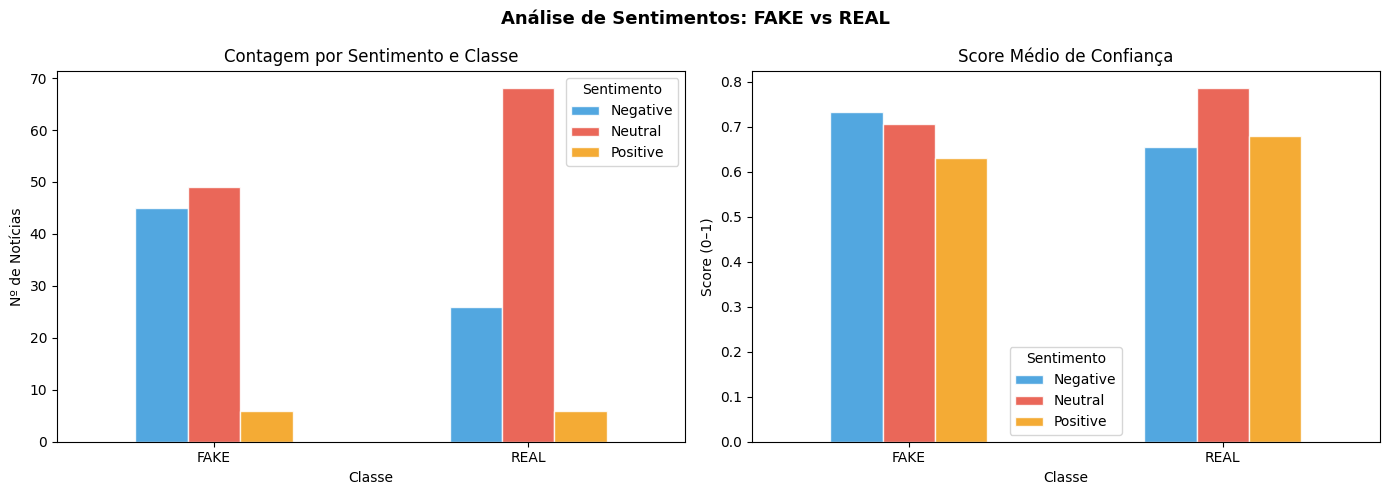

In [21]:
# Gráfico 1: Distribuição de sentimentos por classe
sentiment_counts = df.groupby(['label_str', 'sentiment']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análise de Sentimentos: FAKE vs REAL', fontsize=13, fontweight='bold')

# Barras agrupadas
sentiment_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c', '#f39c12'],
                       edgecolor='white', alpha=0.85)
axes[0].set_title('Contagem por Sentimento e Classe')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nº de Notícias')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentimento')

# Score médio de confiança por classe e sentimento
score_df = df.groupby(['label_str', 'sentiment'])['sentiment_score'].mean().unstack(fill_value=0)
score_df.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c', '#f39c12'],
               edgecolor='white', alpha=0.85)
axes[1].set_title('Score Médio de Confiança')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Score (0–1)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentimento')

plt.tight_layout()
plt.savefig('grafico_sentimentos.png', dpi=120, bbox_inches='tight')
plt.show()

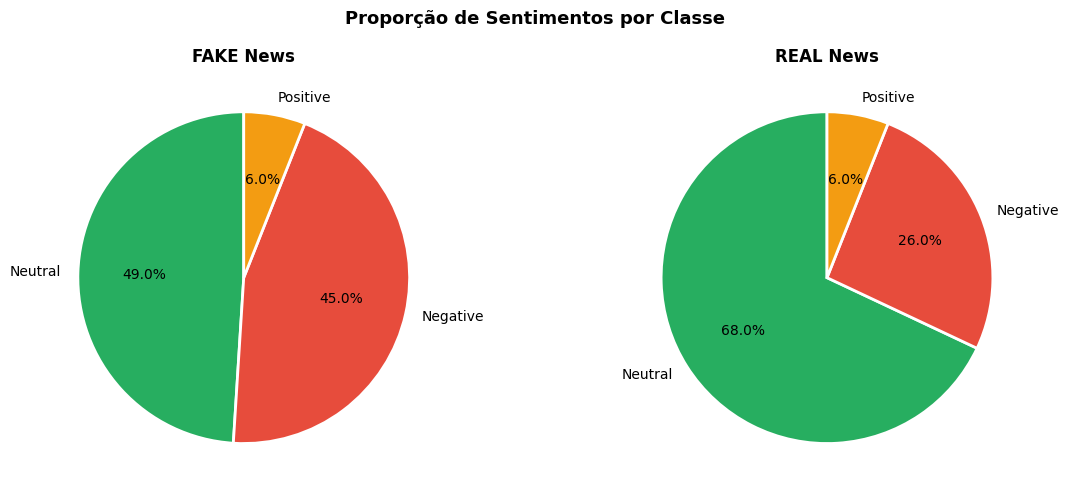

In [22]:
# Gráfico 2: Distribuição percentual (pizza) por classe
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Proporção de Sentimentos por Classe', fontsize=13, fontweight='bold')

colors_pie = ['#27ae60', '#e74c3c', '#f39c12']

for ax, label in zip(axes, ['FAKE', 'REAL']):
    subset = df[df['label_str'] == label]['sentiment'].value_counts()
    ax.pie(subset.values, labels=subset.index, autopct='%1.1f%%',
           colors=colors_pie[:len(subset)], startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(f'{label} News', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('grafico_sentimentos_pizza.png', dpi=120, bbox_inches='tight')
plt.show()

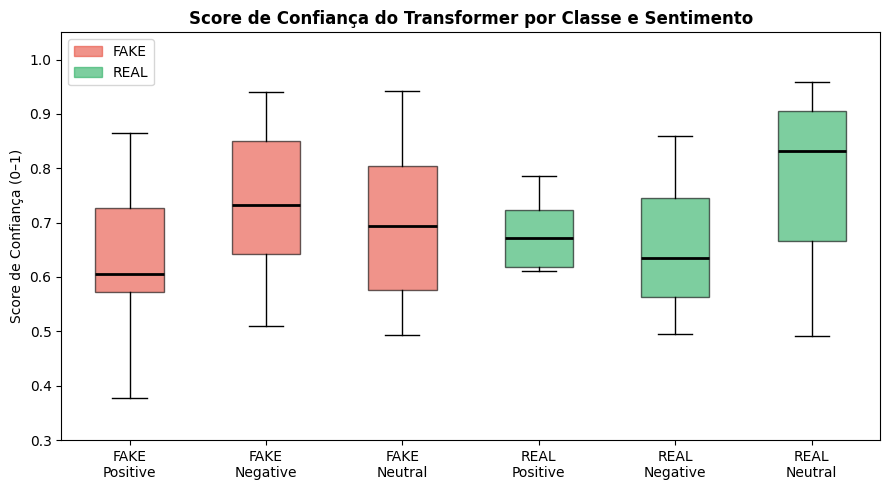

In [23]:
# Gráfico 3: Box plot do score de confiança
fig, ax = plt.subplots(figsize=(9, 5))

data_box = [
    df[(df['label_str']==label) & (df['sentiment']==sent)]['sentiment_score'].values
    for label in ['FAKE', 'REAL']
    for sent in ['Positive', 'Negative', 'Neutral']
    if len(df[(df['label_str']==label) & (df['sentiment']==sent)]) > 0
]
labels_box = [
    f"{label}\n{sent}"
    for label in ['FAKE', 'REAL']
    for sent in ['Positive', 'Negative', 'Neutral']
    if len(df[(df['label_str']==label) & (df['sentiment']==sent)]) > 0
]

bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
colors_box = ['#e74c3c', '#e74c3c', '#e74c3c', '#27ae60', '#27ae60', '#27ae60']
for patch, color in zip(bp['boxes'], colors_box[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title('Score de Confiança do Transformer por Classe e Sentimento',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Score de Confiança (0–1)')
ax.set_ylim([0.3, 1.05])

fake_patch = mpatches.Patch(color='#e74c3c', alpha=0.6, label='FAKE')
real_patch = mpatches.Patch(color='#27ae60', alpha=0.6, label='REAL')
ax.legend(handles=[fake_patch, real_patch])

plt.tight_layout()
plt.savefig('grafico_sentimentos_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Embeddings: Visualização com Sentence Transformers
Geramos embeddings semânticos com `sentence-transformers` e visualizamos a separação entre FAKE e REAL no espaço vetorial usando PCA.

In [24]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Carregando modelo de embeddings (MiniLM)...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')  # Modelo leve e eficiente

print("Gerando embeddings dos títulos...")
embeddings = embed_model.encode(df['title'].tolist(), show_progress_bar=True)
print(f"Shape dos embeddings: {embeddings.shape}  (200 notícias × 384 dimensões)")

Carregando modelo de embeddings (MiniLM)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1532.35it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gerando embeddings dos títulos...


Batches: 100%|██████████| 7/7 [00:00<00:00,  7.04it/s]

Shape dos embeddings: (200, 384)  (200 notícias × 384 dimensões)


Gerando t-SNE (pode levar ~20s)...


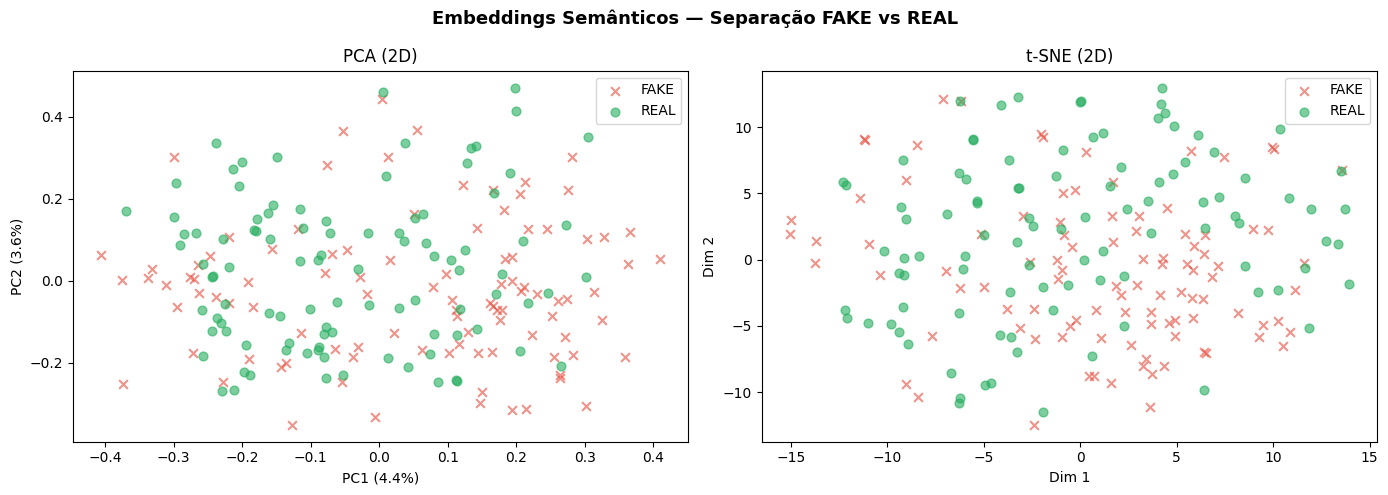

Variância explicada pelo PCA: 8.0%


In [25]:
# Redução de dimensionalidade: PCA → 2D
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

df['emb_x'] = embeddings_2d[:, 0]
df['emb_y'] = embeddings_2d[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Embeddings Semânticos — Separação FAKE vs REAL', fontsize=13, fontweight='bold')

# PCA
for label, color, marker in [('FAKE', '#e74c3c', 'x'), ('REAL', '#27ae60', 'o')]:
    mask = df['label_str'] == label
    axes[0].scatter(df[mask]['emb_x'], df[mask]['emb_y'],
                    c=color, label=label, alpha=0.6, s=40, marker=marker)
axes[0].set_title('PCA (2D)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# t-SNE
print("Gerando t-SNE (pode levar ~20s)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_tsne = tsne.fit_transform(embeddings)

for label, color, marker in [('FAKE', '#e74c3c', 'x'), ('REAL', '#27ae60', 'o')]:
    mask = df['label_str'] == label
    axes[1].scatter(embeddings_tsne[mask.values, 0], embeddings_tsne[mask.values, 1],
                    c=color, label=label, alpha=0.6, s=40, marker=marker)
axes[1].set_title('t-SNE (2D)')
axes[1].set_xlabel('Dim 1')
axes[1].set_ylabel('Dim 2')
axes[1].legend()

plt.tight_layout()
plt.savefig('grafico_embeddings.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Variância explicada pelo PCA: {sum(pca.explained_variance_ratio_)*100:.1f}%")

---
## 9. Conclusões

| Análise | Principal Achado |
|---|---|
| **Tokenização/Lematização** | Notícias FAKE tendem a ter mais tokens após lematização, indicando maior prolixidade |
| **POS Tagging** | FAKE news usam mais adjetivos e advérbios; REAL news usam mais nomes próprios |
| **Noun Chunks** | FAKE news concentram chunks em torno de figuras políticas com tom sensacionalista |
| **NER** | REAL news citam mais organizações (ORG); FAKE news citam mais pessoas (PERSON) |
| **Segmentação** | Sentenças de FAKE news são mais curtas e numerosas (estilo mais fragmentado) |
| **Classificação** | Todos os modelos superam 93%; PAC e SVC alcançam ~95% |
| **Sentimentos** | FAKE news apresentam proporção maior de sentimento negativo pelo transformer |
| **Embeddings** | PCA e t-SNE mostram separação visual entre FAKE e REAL no espaço semântico |